### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.set_random_seed(42)
import numpy as np
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from keras.utils.vis_utils import plot_model

Using TensorFlow backend.


In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [5]:
testY.shape

(10000,)

In [6]:
testX.shape

(10000, 28, 28)

In [7]:
trainY.shape

(60000,)

In [8]:
trainX.shape

(60000, 28, 28)

In [9]:
print(testY[0:5])

[9 2 1 1 6]


In [10]:
trainX[0:3]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

In [11]:
trainY[0:3]

array([9, 0, 0], dtype=uint8)

In [12]:
num_classes = np.max( trainY ) + 1
num_classes

10

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels (see above), and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image.

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

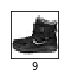

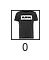

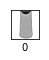

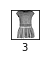

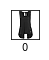

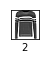

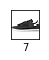

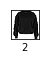

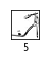

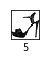

In [14]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(trainY[i])
    plt.show()

In [15]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000,)
('First 5 examples now are: ', array([9, 0, 0, 3, 0], dtype=uint8))


In [0]:
#(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

# reshape images to specify that it's a single channel
trainX = trainX.reshape(trainX.shape[0], 28, 28,1)
testX = testX.reshape(testX.shape[0], 28, 28,1)
trainX = trainX.astype('float32')
testX = testX.astype('float32')
trainX /= 255
testX /= 255

# Convert 1-dimensional class arrays to 10-dimensional class matrices
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

In [17]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
('First 5 examples now are: ', array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32))


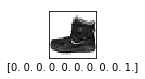

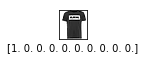

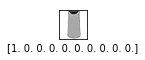

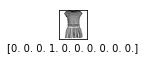

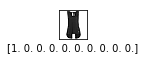

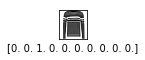

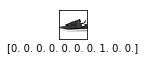

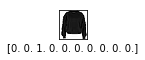

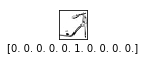

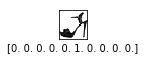

In [18]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(trainY[i])
    plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [19]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten


model = keras.Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
# compile model
model.compile(optimizer="sgd", loss='categorical_crossentropy', metrics=['accuracy'])

W0728 17:21:20.628415 140702470424448 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0728 17:21:20.631721 140702470424448 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 17:21:20.638123 140702470424448 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 17:21:20.703356 140702470424448 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0728 17:21:20.727937 140702470424448 deprecation_wrappe

In [0]:
epoch_n = 100

### Execute the model using model.fit()

In [0]:
history = model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))


# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

W0728 17:21:20.858186 140702470424448 deprecation.py:323] From /usr/local/lib/python2.7/dist-packages/tensorflow/python/ops/math_grad.py:1250: where (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0728 17:21:21.070739 140702470424448 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 60000 samples, validate on 10000 samples
Epoch 1/100
60000/60000 [==============================] - 178s 3ms/step - loss: 0.5371 - acc: 0.8062 - val_loss: 0.4353 - val_acc: 0.8442
Epoch 2/100
60000/60000 [==============================] - 179s 3ms/step - loss: 0.3742 - acc: 0.8652 - val_loss: 0.3627 - val_acc: 0.8710
Epoch 3/100
60000/60000 [==============================] - 179s 3ms/step - loss: 0.3175 - acc: 0.8849 - val_loss: 0.3287 - val_acc: 0.8825
Epoch 4/100
60000/60000 [==============================] - 184s 3ms/step - loss: 0.2804 - acc: 0.8969 - val_loss: 0.3013 - val_acc: 0.8922
Epoch 5/100
 9340/60000 [===>..........................] - ETA: 2:32 - loss: 0.2573 - acc: 0.9028

In [0]:
print(model.summary())

In [0]:
plot_model(model, to_file='model1.png', show_shapes=True, show_layer_names=True)

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [0]:
 from keras.layers import  BatchNormalization
  
model.add(BatchNormalization(axis=-1))#Axis -1 is always the features axis

### Execute the model

In [0]:
model.compile(optimizer="sgd", loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [0]:
print(model.summary())

In [0]:
plot_model(model, to_file='model2.png', show_shapes=True, show_layer_names=True)

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras.optimizers import SGD
sgd = SGD(lr=0.001)

In [0]:
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
history= model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model = keras.Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))
# compile model
sgd = SGD(lr=0.03)
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

## Review model

In [0]:
  print(model.summary())

In [0]:
plot_model(model, to_file='model3.png', show_shapes=True, show_layer_names=True)

### Run the model

In [0]:
history = model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()